## Assignment #2
**Author:** Nataliia Kobrii (UTORid: qq566325)

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

Open the housing data

In [2]:
import os

HOUSING_PATH = "."

def load_housing_data(housing_path=HOUSING_PATH):
    csv_path = os.path.join(housing_path, "housing.csv")
    return pd.read_csv(csv_path)

housing = load_housing_data()
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


Basic EDA of the housing data

In [3]:
# Summary Statistics
print("Summary Statistics:")
housing.describe().round(2)

Summary Statistics:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.00,20640.00,20640.00,20640.00,20433.00,20640.00,20640.00,20640.00,20640.00
mean,-119.57,35.63,28.64,2635.76,537.87,1425.48,499.54,3.87,206855.82
std,2.00,2.14,12.59,2181.62,421.39,1132.46,382.33,1.90,115395.62
min,-124.35,32.54,1.00,2.00,1.00,3.00,1.00,0.50,14999.00
25%,-121.80,33.93,18.00,1447.75,296.00,787.00,280.00,2.56,119600.00
50%,-118.49,34.26,29.00,2127.00,435.00,1166.00,409.00,3.53,179700.00
75%,-118.01,37.71,37.00,3148.00,647.00,1725.00,605.00,4.74,264725.00
max,-114.31,41.95,52.00,39320.00,6445.00,35682.00,6082.00,15.00,500001.00


In [4]:
# Missing Values
print("Missing Values:")
print(housing.isnull().sum())

Missing Values:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


In [5]:
# Data Types
print("Data Types:")
print(housing.dtypes)

Data Types:
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object


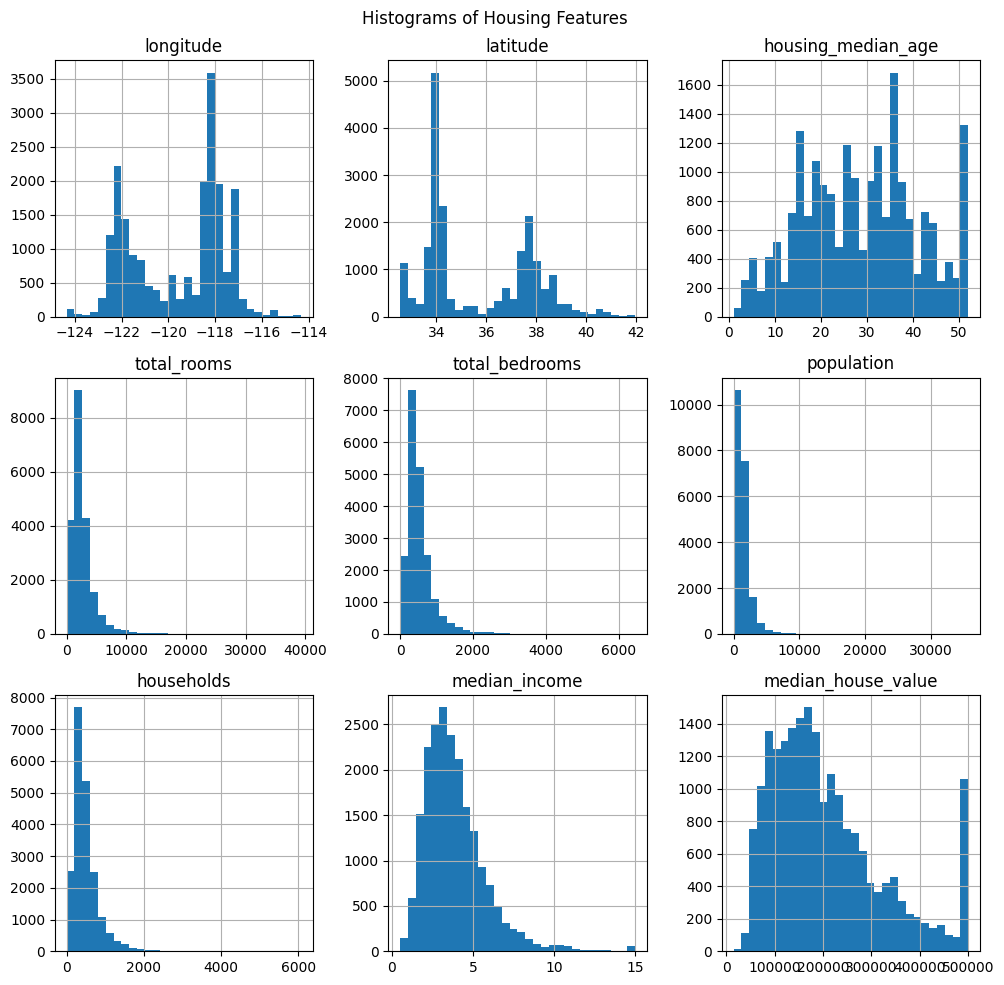

In [6]:
# Histograms
housing.hist(bins=30, figsize=(10, 10))
plt.suptitle("Histograms of Housing Features")
plt.tight_layout()
plt.show()

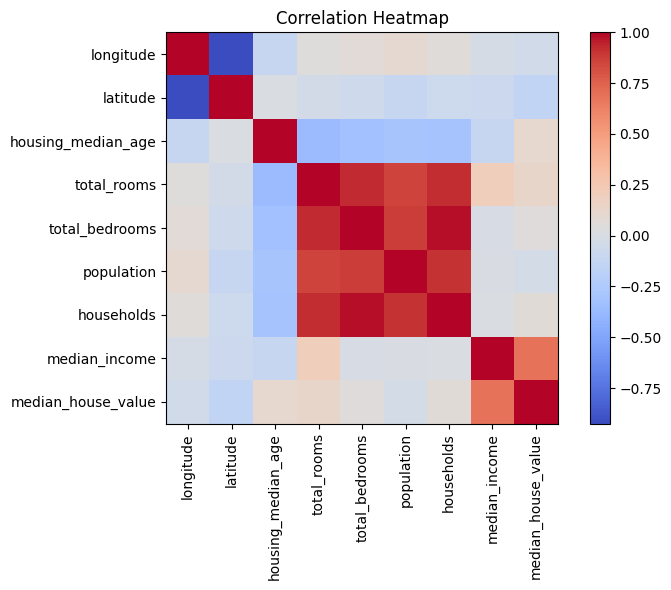

In [7]:
# Correlation Heatmap
housing_numeric = housing.select_dtypes(include=[np.number])

plt.figure(figsize=(8, 6))
correlation_matrix = housing_numeric.corr()
plt.imshow(correlation_matrix, cmap='coolwarm', interpolation='none')
plt.colorbar()
plt.xticks(range(len(correlation_matrix)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix)), correlation_matrix.columns)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

### Build full pipeline for the data analysis following the example of the notebook.
 Hint: the main part requested to change is the algorithm used (KNN regression)

#### Considerations for building pipeline:

- Make your notebook as compact as possible. 
- Split data into training and testing sets below.
- Convert all categorical data to one-hot vectors below
- Normalize all non-categorical data 
-  Perform KNN regression using a variety of values for n_neighbors (K) between 1 and 10 and both "uniform" and "distance" weights via a grid search where  *housing_labels* is the output and all other features are the input (similar to as seen in lecture two.)

In [8]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

In [9]:
# Save a scaler for the target column to inverse-transform predictions later
target_scaler = MinMaxScaler()
housing[['median_house_value']] = target_scaler.fit_transform(housing[['median_house_value']])

In [10]:
# One-hot encode categorical columns
housing_encoded = pd.get_dummies(housing)

In [11]:
# Normalize all numeric features using Min-Max scaling
numeric_cols = housing_encoded.select_dtypes(include=[np.number]).columns
scaler = MinMaxScaler()
housing_encoded[numeric_cols] = scaler.fit_transform(housing_encoded[numeric_cols])

In [12]:
# Drop rows with NaN values and split into train/test
housing_encoded = housing_encoded.dropna()
train_set, test_set = train_test_split(housing_encoded, test_size=0.2, random_state=42)

In [13]:
# Separate features and labels
housing_features = train_set.drop('median_house_value', axis=1)
housing_labels = train_set['median_house_value']

test_features = test_set.drop('median_house_value', axis=1)
test_labels = test_set['median_house_value']

In [14]:
# Grid search over K (1-10) and weight options (uniform, distance)
param_grid = {
    'n_neighbors': range(1, 11),
    'weights': ['uniform', 'distance']
}

knn = KNeighborsRegressor()
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(housing_features, housing_labels)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score (neg MSE): {grid_search.best_score_:.6f}")

Best Parameters: {'n_neighbors': 9, 'weights': 'distance'}
Best Cross-Validation Score (neg MSE): -0.016075


In [15]:
# Generate predictions on the test set
predictions = grid_search.predict(test_features)

In [16]:
# Inverse transform to original dollar units
predictions_dollars = target_scaler.inverse_transform(predictions.reshape(-1, 1))
test_labels_dollars = target_scaler.inverse_transform(test_labels.values.reshape(-1, 1))

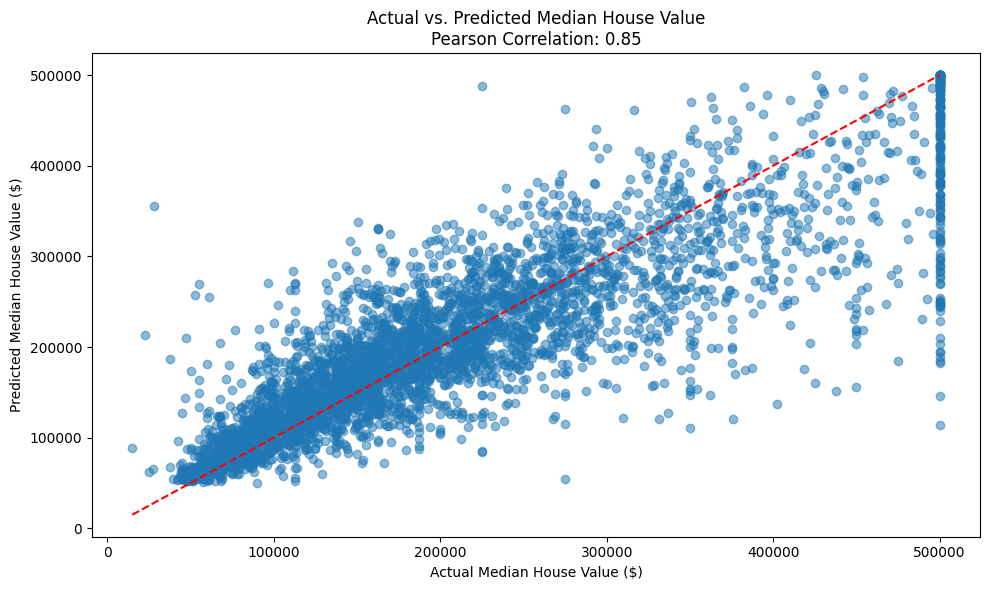

In [17]:
# Scatterplot: Actual vs Predicted
pearson_corr = np.corrcoef(test_labels, predictions)[0, 1]

plt.figure(figsize=(10, 6))
plt.scatter(test_labels_dollars, predictions_dollars, alpha=0.5)
plt.plot([test_labels_dollars.min(), test_labels_dollars.max()],
         [test_labels_dollars.min(), test_labels_dollars.max()], 'r--')
plt.xlabel('Actual Median House Value ($)')
plt.ylabel('Predicted Median House Value ($)')
plt.title(f'Actual vs. Predicted Median House Value\nPearson Correlation: {pearson_corr:.2f}')
plt.tight_layout()
plt.show()

In [18]:
# Validation metrics
mse = mean_squared_error(test_labels_dollars, predictions_dollars)
rmse = np.sqrt(mse)
r2 = r2_score(test_labels_dollars, predictions_dollars)

print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"R-squared (R²): {r2:.4f}")

Mean Squared Error (MSE): 3,759,614,280.38
Root Mean Squared Error (RMSE): 61,315.69
R-squared (R²): 0.7223


### Conclusions
For what values of n_neighbors and weight does KNeighborsRegressor perform the best? Does it perform as well on the housing data as the linear regressor from the lectures? Why do you think this is?

<pre> The best parameters found through grid search were n_neighbors=9 with weights='distance'. 
KNN regression achieved an R² of approximately 0.72 on the test set, which is comparable to but 
slightly lower than what a well-tuned linear regression can achieve on this dataset. 

KNN is a non-parametric method that captures local patterns well, but it can struggle with 
high-dimensional data due to the curse of dimensionality. The housing dataset has multiple features, 
which means distances between points become less meaningful in higher dimensions. Linear regression, 
on the other hand, can capture global trends efficiently and benefits from strong linear correlations 
like median_income vs. median_house_value. 

Distance-weighted KNN outperformed uniform weighting because closer neighbors are more relevant 
for prediction, giving them higher influence reduces noise from farther neighbors. </pre>

### Read Appendix B

- Reflect on your last data project, read appendix B. Then, write down a few of the checklist items that your last data project could have used. If you have not yet done a data project, then write down a few of the items that you found most interesting.

From the ML project checklist in Appendix B, the following items stood out as areas for improvement:
* More thorough exploratory data analysis, including examining feature distributions and identifying outliers before modeling.
* Systematic hyperparameter tuning and model comparison rather than relying on a single algorithm.
* A proper model evaluation pipeline with cross-validation and multiple performance metrics.
* Documentation and presentation of results to stakeholders, including model limitations and assumptions.

### Submit your notebook

Submit your solution to Quercus  
Make sure you rename your notebook to    
W2_UTORid.ipynb    
Example W2_adfasd01.ipynb